In [1]:
%run -i ../../python_scripts/nb_setup.py

GPU Available: True
GPU Name: NVIDIA GeForce RTX 4060


#### Choose the dataset you want to use :
* must be data the model did not see at training
* first column : __y_true__ $\in \{0,1\}$ are the samples labels  
* second column : __y_pred__ are the predicted class of samples ($\in \{0,1\}$ too)
* third column : __kappa_f__ is confidence function for each sample, $\in \mathbb{R}$

In [2]:
sgp_df_SR = pickle.load(open('sgp_set_cnn','rb')) 
print(sgp_df_SR.shape)
print('Propotion of 1s: ', np.round(sgp_df_SR.y_true.sum()/sgp_df_SR.shape[0],2))
sgp_df_SR.head() 

(40000, 3)
Propotion of 1s:  0.1


,y_true,y_pred,kappa
0,0.0,0.0,0.968736
1,0.0,1.0,0.870544
2,0.0,0.0,0.882295
3,0.0,0.0,0.768718
4,0.0,1.0,0.739913


In [24]:
delta = 0.01
d0 = 1

In [10]:
from python_scripts.sgp_utils import bound, B_star, emp_errs_count

In [39]:
our_bounds = []
ucecm_bounds = []
thetas = np.linspace(0.5, 0.95, 50)

for theta in thetas:
    selected_samples = sgp_df_SR.loc[sgp_df_SR.kappa >= theta].copy()
    selected_errs_count = emp_errs_count(selected_samples, loss = 'FP')
    b = B_star(delta/2, 
            selected_errs_count,
            selected_samples.shape[0])    
    B = bound(b, selected_samples, delta/2, 'FPR', n=sgp_df_SR.shape[0])
    our_bounds.append(B)

    a = (selected_samples.y_pred*(1-selected_samples.y_true)).sum()/(1-selected_samples.y_true).sum() 
    b = np.sqrt(1000*(d0*np.log(8*sgp_df_SR.shape[0])+np.log(4/delta))/(1-selected_samples.y_true).sum())
    ucecm_bounds.append(a+b)

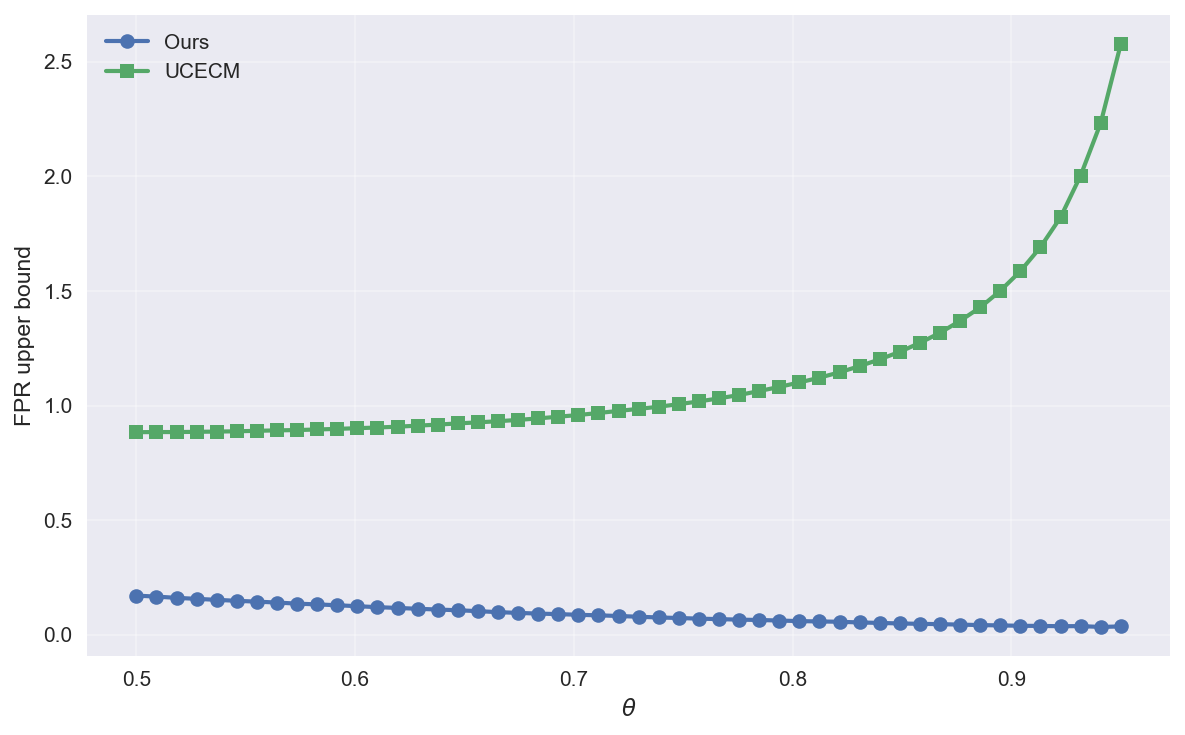

In [40]:
plt.style.use("seaborn-v0_8")   # Nice modern style

plt.figure(figsize=(8, 5))
plt.plot(thetas, our_bounds, marker="o", linewidth=2, label="Ours")
plt.plot(thetas, ucecm_bounds, marker="s", linewidth=2, label="UCECM")

plt.xlabel(r"$\theta$")
plt.ylabel("FPR upper bound")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()
